### Exercício 01 - Subespaço

Considere, em $\mathbb{R}^3$, o plano dado pela equação $x+y-z=0$.
Os vetores $u=[1, 0, 1]^\top$ e $v=[0, 1, 1]^\top$ pertencem a tal plano (como verificar esta afirmação?). Qualquer combinação linear $w=au + bv$, com $a,b\in \mathbb{R}$, pertence ao plano, pois

$$
w = \begin{bmatrix} a \\ b \\ a+b \end{bmatrix}.
$$

Logo o plano corresponde a um subespaço de $\mathbb{R}^3$.
- Implemente uma visualização desse subespaço com os vetores $u$ e $v$ e uma combinação linear qualquer desses vetores.

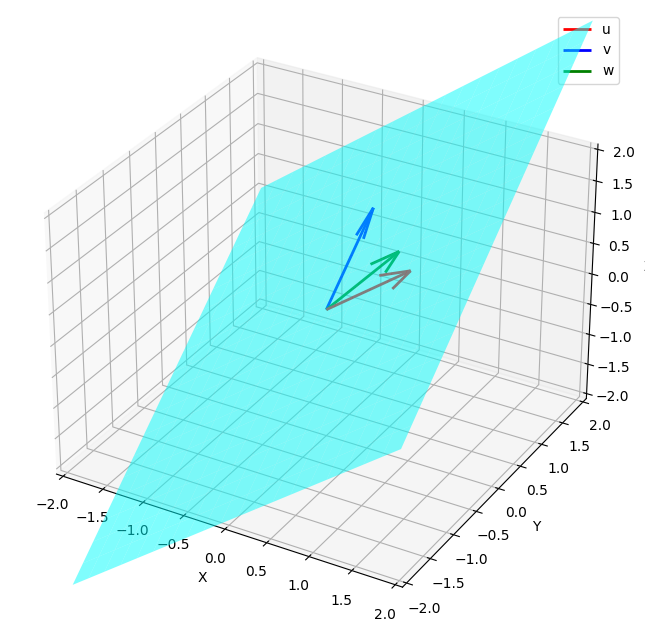

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Vetores bases do plano
u = np.array([1, 0, 1])
v = np.array([0, 1, 1])

# Gera pontos os coeficientes das combinações lineares, variando de -2 a 2
s = np.linspace(-2, 2, 20)  # coeficientes de u
t = np.linspace(-2, 2, 20)  # coeficientes de v
S, T = np.meshgrid(s, t)

# Gera as combinações lineares: cada ponto do plano é P = s*u + t*v
X = S*u[0] + T*v[0]
Y = S*u[1] + T*v[1]
Z = S*u[2] + T*v[2]

# Plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Gera a superfície do plano
ax.plot_surface(X, Y, Z, alpha=0.5, color="cyan")
# ax.plot_wireframe(X, Y, Z, color="cyan")

# Vetor w
alpha = 0.7
beta = 0.3
w_x = u[0]*alpha + v[0]*beta
w_y = u[1]*alpha + v[1]*beta
w_z = u[2]*alpha + v[2]*beta
w = (w_x, w_y, w_z)

# Gera os vetores u, v e w
ax.quiver(0, 0, 0, u[0], u[1], u[2], color="red", linewidth=2, label="u")
ax.quiver(0, 0, 0, v[0], v[1], v[2], color="blue", linewidth=2, label="v")
ax.quiver(0, 0, 0, w[0], w[1], w[2], color="green", linewidth=2, label="w")

# Ajusta limites e rótulos
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
ax.set_zlim([-2, 2])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.show()

### Exercício 02 - Mudança de base
Considere a base $B$ de $\mathbb{R}^3$ formada pelos vetores $(1,0,1)$, $(1,1,1)$ e $(1,1,2)$. Considere também a base $C$ formada pelos vetores $(1,0,0)$, $(0,1,0)$ e $(0,0,1)$.
- Calcule $M_B^C$ e $M_C^B$
- Generalize o cálculo da matriz de mudança de base em uma função.
- Sejam as coordenadas do vetor $v$ em relação a base $C$ dadas por $v_C = [8, 7, 1]^\top$. Calcule as coordenadas do vetor $v$ em relação a base $B$.

In [8]:
import numpy as np

# Bases (vetores são as colunas)
B = np.array(([1, 1, 1],
             [0, 1, 1],
             [1, 1, 2]))
C = np.array(([1, 0, 0],
             [0, 1, 0],
             [0, 0, 1]))

# Calculando M_B^C e M_C^B específicos para os valores dados
M_BC = B                    # como C é a base canônica, a matriz de B para C é o próprio B
M_CB = np.linalg.inv(B)     # matriz inversa

print("Cálculo específico:")
print("M_BC:\n",  M_BC)
print("M_CB:\n", M_CB)

# Função para generalizar
def mudanca_base(base_orig, base_dest):
    return np.linalg.inv(base_dest) @ base_orig     # Resultado válido para bases com vetores escritos na mesma base de referência (normalmente canônica)

M_BC = mudanca_base(B, C)
M_CB = mudanca_base(C, B)

print("\nCálculo generalizado (função):")
print("M_BC:\n",  M_BC)
print("M_CB:\n", M_CB)

# Calculando a mudança de base do vetor v
v_c = np.array([8, 7, 1])
v_b = M_CB @ v_c
v_c = M_BC @ v_b    # só para verificar se deu certo

print("\n V na base B:\n", v_b)
print("\n V na base C:\n", v_c)

Cálculo específico:
M_BC:
 [[1 1 1]
 [0 1 1]
 [1 1 2]]
M_CB:
 [[ 1. -1.  0.]
 [ 1.  1. -1.]
 [-1.  0.  1.]]

Cálculo generalizado (função):
M_BC:
 [[1. 1. 1.]
 [0. 1. 1.]
 [1. 1. 2.]]
M_CB:
 [[ 1. -1.  0.]
 [ 1.  1. -1.]
 [-1.  0.  1.]]

 V na base B:
 [ 1. 14. -7.]

 V na base C:
 [8. 7. 1.]
